# SAMOS pipeline walkthrough — Step07

This notebook documents **Step07** of the SAMOS pipeline: arc processing and wavelength calibration.

Step07 takes the full-frame arc products and turns them into:

- a cleaned canonical arc image
- per-slit 1D arc spectra
- inter-slit shift measurements
- a master arc spectrum
- a global wavelength solution
- propagated wavelength vectors for all slits

The Step07 flow is:

```text
Step07a → arc difference
Step07b → pixel-flat correction of arc
Step07c → 1D extraction per slit
Step07d → initial bright-line shifts
Step07e → refined shifts
Step07f → build master arc
Step07g → solve global wavelength solution
Step07h → propagate wavelength solution to all slits
```

This notebook keeps the **infrastructure explicit** and then builds a **scientific QC ladder** from early arc geometry to final wavelength-space validation.


In [58]:
from pathlib import Path
import os
import sys

def find_repo_root(start: Path):
    candidates = [start] + list(start.parents)
    for p in candidates:
        cfg_dir = p / "config"
        if cfg_dir.is_dir() and (cfg_dir / "__init__.py").exists():
            return p
    return None

repo_env = os.environ.get("SAMOS_REPO_ROOT", "").strip()
if repo_env:
    REPO_ROOT = Path(repo_env).expanduser().resolve()
else:
    REPO_ROOT = find_repo_root(Path.cwd())

if REPO_ROOT is None:
    raise RuntimeError(
        "Could not find the SAMOS repository root. "
        "Run this notebook from inside the repo tree, or set SAMOS_REPO_ROOT."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import config

print("Repo root        :", REPO_ROOT)
print("Step03.5 input   :", config.ST03P5_ROWSTRIPE)
print("Step04 output dir:", config.ST04_TRACES)
print("Step05 output dir:", config.ST05_PIXFLAT)
print("Step07 output dir:", config.ST07_WAVECAL)
print("Master arc diff  :", getattr(config, "MASTER_ARC_DIFF", "not defined"))
print("Master arc fits  :", getattr(config, "MASTER_ARC_FITS", "not defined"))
print("YWIN0            :", getattr(config, "WAVECAL_YWIN0", "not defined"))
print("FIRSTLEN         :", getattr(config, "WAVECAL_FIRSTLEN", "not defined"))


Repo root        : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Step03.5 input   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/20260113/preprocessed/03p5_rowstripe
Step04 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/04_traces
Step05 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat
Step07 output dir: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal
Master arc diff  : /Users/robberto/Library/CloudStorag

## Notebook infrastructure

This notebook may live outside the repository root, for example under `drivers/Jupyter/`. Because of that, all pipeline and QC scripts should be executed through a helper that resolves paths relative to `REPO_ROOT`, not relative to the notebook working directory.


In [36]:
from pathlib import Path
import subprocess
import os
import sys

PYTHON = sys.executable

def run_repo_script(relpath: str, *args, check: bool = True):
    script = REPO_ROOT / relpath
    if not script.exists():
        raise FileNotFoundError(f"Script not found: {script}")

    env = os.environ.copy()
    old_pp = env.get("PYTHONPATH", "")
    env["PYTHONPATH"] = str(REPO_ROOT) + (os.pathsep + old_pp if old_pp else "")

    cmd = [PYTHON, str(script), *map(str, args)]
    print("Running:", " ".join(cmd))
    print("cwd     :", REPO_ROOT)
    print("PYTHONPATH:", env["PYTHONPATH"])

    return subprocess.run(
        cmd,
        check=check,
        cwd=str(REPO_ROOT),
        env=env,
    )

def repo_path(relpath: str) -> Path:
    return REPO_ROOT / relpath


## 1. Conceptual structure of Step07

Step07 performs wavelength calibration using arc lamp exposures.

At a high level:

1. build the canonical arc-difference image
2. apply the pixel flat inside the slit masks
3. extract one 1D arc spectrum per slit
4. measure relative inter-slit shifts
5. refine those shifts conservatively
6. build a master arc spectrum
7. derive a global wavelength solution on the master
8. propagate the solution to every slit

The key scientific idea is:

- detector Y remains the independent pixel coordinate
- the master arc defines the global pixel-to-wavelength mapping
- each slit receives that solution through its `SHIFT_TO_MASTER` bookkeeping


## 2. Critical dependencies and file flow

### Step07a reads
- Step03.5 arc ON and OFF frames from `config.ST03P5_ROWSTRIPE`

### Step07b reads
- canonical Step07a arc difference
- Step05 pixel flats
- Step04 masks

### Step07c reads
- Step07b full-frame arc
- Step04 slitid maps
- Step04 geometry metadata

### Step07d–e read
- Step07c per-slit 1D arc products

### Step07f reads
- Step07c arc1d products
- Step07e refined shifts

### Step07g reads
- Step07f master arc
- Step07c arc1d products
- NIST line lists

### Step07h reads
- Step07g master wavelength solution
- Step07f shift bookkeeping
- Step07c arc1d products


In [56]:
# Check the key Step07 infrastructure
from pathlib import Path

st04 = Path(config.ST04_TRACES)
st05 = Path(config.ST05_PIXFLAT)
st07 = Path(config.ST07_WAVECAL)

print(REPO_ROOT / "step08_extract_1d")
print('st07 =',st07,'\n')

check_paths = [
    Path(getattr(config, "MASTER_ARC_DIFF", st07 / "arc_diff.fits")),
    Path(getattr(config, "PIXFLAT_EVEN", st05 / "PixelFlat_from_quartz_diff_EVEN.fits")),
    Path(getattr(config, "PIXFLAT_ODD", st05 / "PixelFlat_from_quartz_diff_ODD.fits")),
    st04 / "Even_traces_geometry.fits",
    st04 / "Odd_traces_geometry.fits",
    st04 / "Even_traces_slitid.fits",
    st04 / "Odd_traces_slitid.fits",
]

for p in check_paths:
    print(f"{p.exists():5}  {p}")

BASE_WAV_FITS = st07 / "arc_1d_wavelength_all.fits"
TRIAL_WAV_FITS = st07 / "arc_1d_wavelength_all_trial_tweak.fits"

print("BASE_WAV_FITS  =", BASE_WAV_FITS)
print("TRIAL_WAV_FITS =", TRIAL_WAV_FITS, TRIAL_WAV_FITS.exists())

/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/step08_extract_1d
st07 = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal 

    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat/PixelFlat_from_quartz_diff_EVEN.fits
    1  /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/05_pixflat/PixelFlat_fr

## 3. Step07a — build the arc difference image

Step07a forms the canonical arc-difference image:

```text
ArcDiff = ARC_SLITS_ON - ARC_SLITS_OFF
```

This isolates the calibration lamp emission lines while suppressing continuum/background. No geometry changes are allowed here.


In [38]:
# Uncomment to run Step07a
run_repo_script("pipeline/step07_wavecal/step07a_make_arc_diff.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07a_make_arc_diff.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr.fits


2026-04-10 20:48:59,334 | WARNING  | astropy | VerifyWarning: Keyword name 'ARC_OFF_P' is greater than 8 characters or contains characters not allowed by the FITS standard; a HIERARCH card will be created.


CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07a_make_arc_diff.py'], returncode=0)

## 4. Step07b — apply pixel-flat correction to the arc image

Step07b is the arc analogue of Step06b.

It applies:

- EVEN flat inside EVEN mask
- ODD flat inside ODD mask

Outside the masks, the arc-difference image is left unchanged.


In [5]:
# Uncomment to run Step07b
run_repo_script("pipeline/step07_wavecal/step07b_apply_pixflat_arc.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07b_apply_pixflat_arc.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
ST07_WAVECAL = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal
Input ArcDiff = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr.fits
EVEN mask = /Users/robberto

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07b_apply_pixflat_arc.py'], returncode=0)

In [6]:
from pathlib import Path

st07 = Path(config.ST07_WAVECAL)
for p in sorted(st07.glob("*pixflatcorr_clipped*.fits")):
    print(p.name)


ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped.fits
ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_ODD.fits


## 5. Step07c — extract 1D arc spectra per slit

Step07c uses the Step04 slitid maps as the authoritative slit footprint definition and extracts one 1D arc spectrum per slit.

Each extension in the output MEF is named `SLIT###` and typically contains:

- `data[0]` = extracted arc flux as a function of detector Y
- `data[1]` = number of contributing pixels per row


In [7]:
# Uncomment to run Step07c
run_repo_script("pipeline/step07_wavecal/step07c_extract_arc_1d.py", "--traceset", "EVEN")
run_repo_script("pipeline/step07_wavecal/step07c_extract_arc_1d.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07c_extract_arc_1d.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
Extracted 32 slits: 0..62
Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_H

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07c_extract_arc_1d.py', '--traceset', 'ODD'], returncode=0)

In [8]:
from pathlib import Path
from astropy.io import fits

st07 = Path(config.ST07_WAVECAL)
arc1d_files = sorted(st07.glob("*_1D_slitid_*.fits"))
for p in arc1d_files:
    print(p.name)

if arc1d_files:
    with fits.open(arc1d_files[0]) as hdul:
        print("\nUsing:", arc1d_files[0].name)
        print("N HDUs =", len(hdul))
        print("First extension names:", [h.name for h in hdul[:6]])


ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_ODD.fits

Using: ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
N HDUs = 33
First extension names: ['PRIMARY', 'SLIT000', 'SLIT002', 'SLIT004', 'SLIT006', 'SLIT008']


### Step07c QC — overlay Step04 geometry on the arc image

This QC overlays the Step04 quartz-derived trace geometry on the full-frame Step07b arc image.

It answers a direct question:

> Is the intended arc ridge still the one being captured by the Step04 slit geometry?


In [9]:
# Uncomment to run the Step07c geometry-over-arc QC
run_repo_script("qc/step07/qc07c_overlay_step04_geometry_on_arc.py", "--traceset", "EVEN")
run_repo_script("qc/step07/qc07c_overlay_step04_geometry_on_arc.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07c_overlay_step04_geometry_on_arc.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
[INFO] Arc image: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped.fits
[INFO] Geometry : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07c_overlay_step04_geometry_on_arc.py', '--traceset', 'ODD'], returncode=0)

## 6. Step07d — initial bright-line shifts

Step07d finds the brightest arc line in each slit and measures its relative shift with respect to a reference slit.

Outputs include:

- `Arc_shifts_initial_<EVEN|ODD>.csv`
- `Arc_stack_aligned_<EVEN|ODD>.fits`


In [10]:
# Uncomment to run Step07d
run_repo_script("pipeline/step07_wavecal/step07d_find_line_shifts.py", "--traceset", "EVEN")
run_repo_script("pipeline/step07_wavecal/step07d_find_line_shifts.py", "--traceset", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07d_find_line_shifts.py --traceset EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
TRACE_SET   = EVEN
ARC1D_FITS  = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
OUT_CSV     = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_202

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07d_find_line_shifts.py', '--traceset', 'ODD'], returncode=0)

In [11]:
# Uncomment to run Step07d QC
run_repo_script("qc/step07/qc07d_inspect_bright_line_alignment.py", "--set", "EVEN")
run_repo_script("qc/step07/qc07d_inspect_bright_line_alignment.py", "--set", "ODD")

Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07d_inspect_bright_line_alignment.py --set EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
TRACE_SET  = EVEN
ARC1D_FITS = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
CSV        = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/D

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07d_inspect_bright_line_alignment.py', '--set', 'ODD'], returncode=0)

## 7. Step07e — refine the shifts conservatively

Step07e starts from the Step07d initial shifts and performs a limited cross-correlation refinement around the bright-line window.

It writes:

- `Arc_shifts_final_<EVEN|ODD>.csv`
- `Arc_stack_aligned_final_<EVEN|ODD>.fits`


In [12]:
# Uncomment to run Step07e
run_repo_script("pipeline/step07_wavecal/step07e_refine_stack_arc.py", "--set", "EVEN")
run_repo_script("pipeline/step07_wavecal/step07e_refine_stack_arc.py", "--set", "ODD")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07e_refine_stack_arc.py --set EVEN
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
ARC1D_FITS = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
SHIFT0_CSV = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduce

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07e_refine_stack_arc.py', '--set', 'ODD'], returncode=0)

## 8. Step07f — build the master arc

Step07f merges the refined slit spectra into a common master frame while preserving explicit shift bookkeeping.

The `SLITLIST` table is scientifically important because it stores:

- `SHIFT_FINAL`
- `SHIFT_GLOBAL`
- `SHIFT_TO_MASTER`


In [13]:
# Uncomment to run Step07f
run_repo_script("pipeline/step07_wavecal/step07f_build_master_arc.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07f_build_master_arc.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
EVEN ARC1D  = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
EVEN SHIFTS = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wave

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07f_build_master_arc.py'], returncode=0)

### Note on Step07f QC

A dedicated Step07f QC script exists, but it is omitted from the default notebook flow until its parser is cleaned up. In practice, the master arc is still validated downstream because Step07g depends directly on it, and the later wavelength-solution QC is scientifically more important.


## 9. Step07g — solve the global wavelength solution

Step07g derives the global polynomial wavelength solution on the master arc and then propagates it to per-slit wavelength solutions.

Typical outputs:

- `arc_master_wavesol.fits`
- `arc_wavesol_per_slit.fits`


In [14]:
# Uncomment to run Step07g
run_repo_script("pipeline/step07_wavecal/step07g_solve_wavelength.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07g_solve_wavelength.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


2026-04-10 19:09:57,020 | INFO     | step07g_solve_wavelength | MASTER_FITS = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master.fits
2026-04-10 19:09:57,020 | INFO     | step07g_solve_wavelength | ARC1D_EVEN  = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
2026-04-10 19:09:57,020 | INFO     | step07g_solve_wavelength | ARC1D_ODD   = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_ODD.fits
2026-04-10 19:09:57,020 | INFO  

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07g_solve_wavelength.py'], returncode=0)

### ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_with_Even_traces_geometry_montage.png

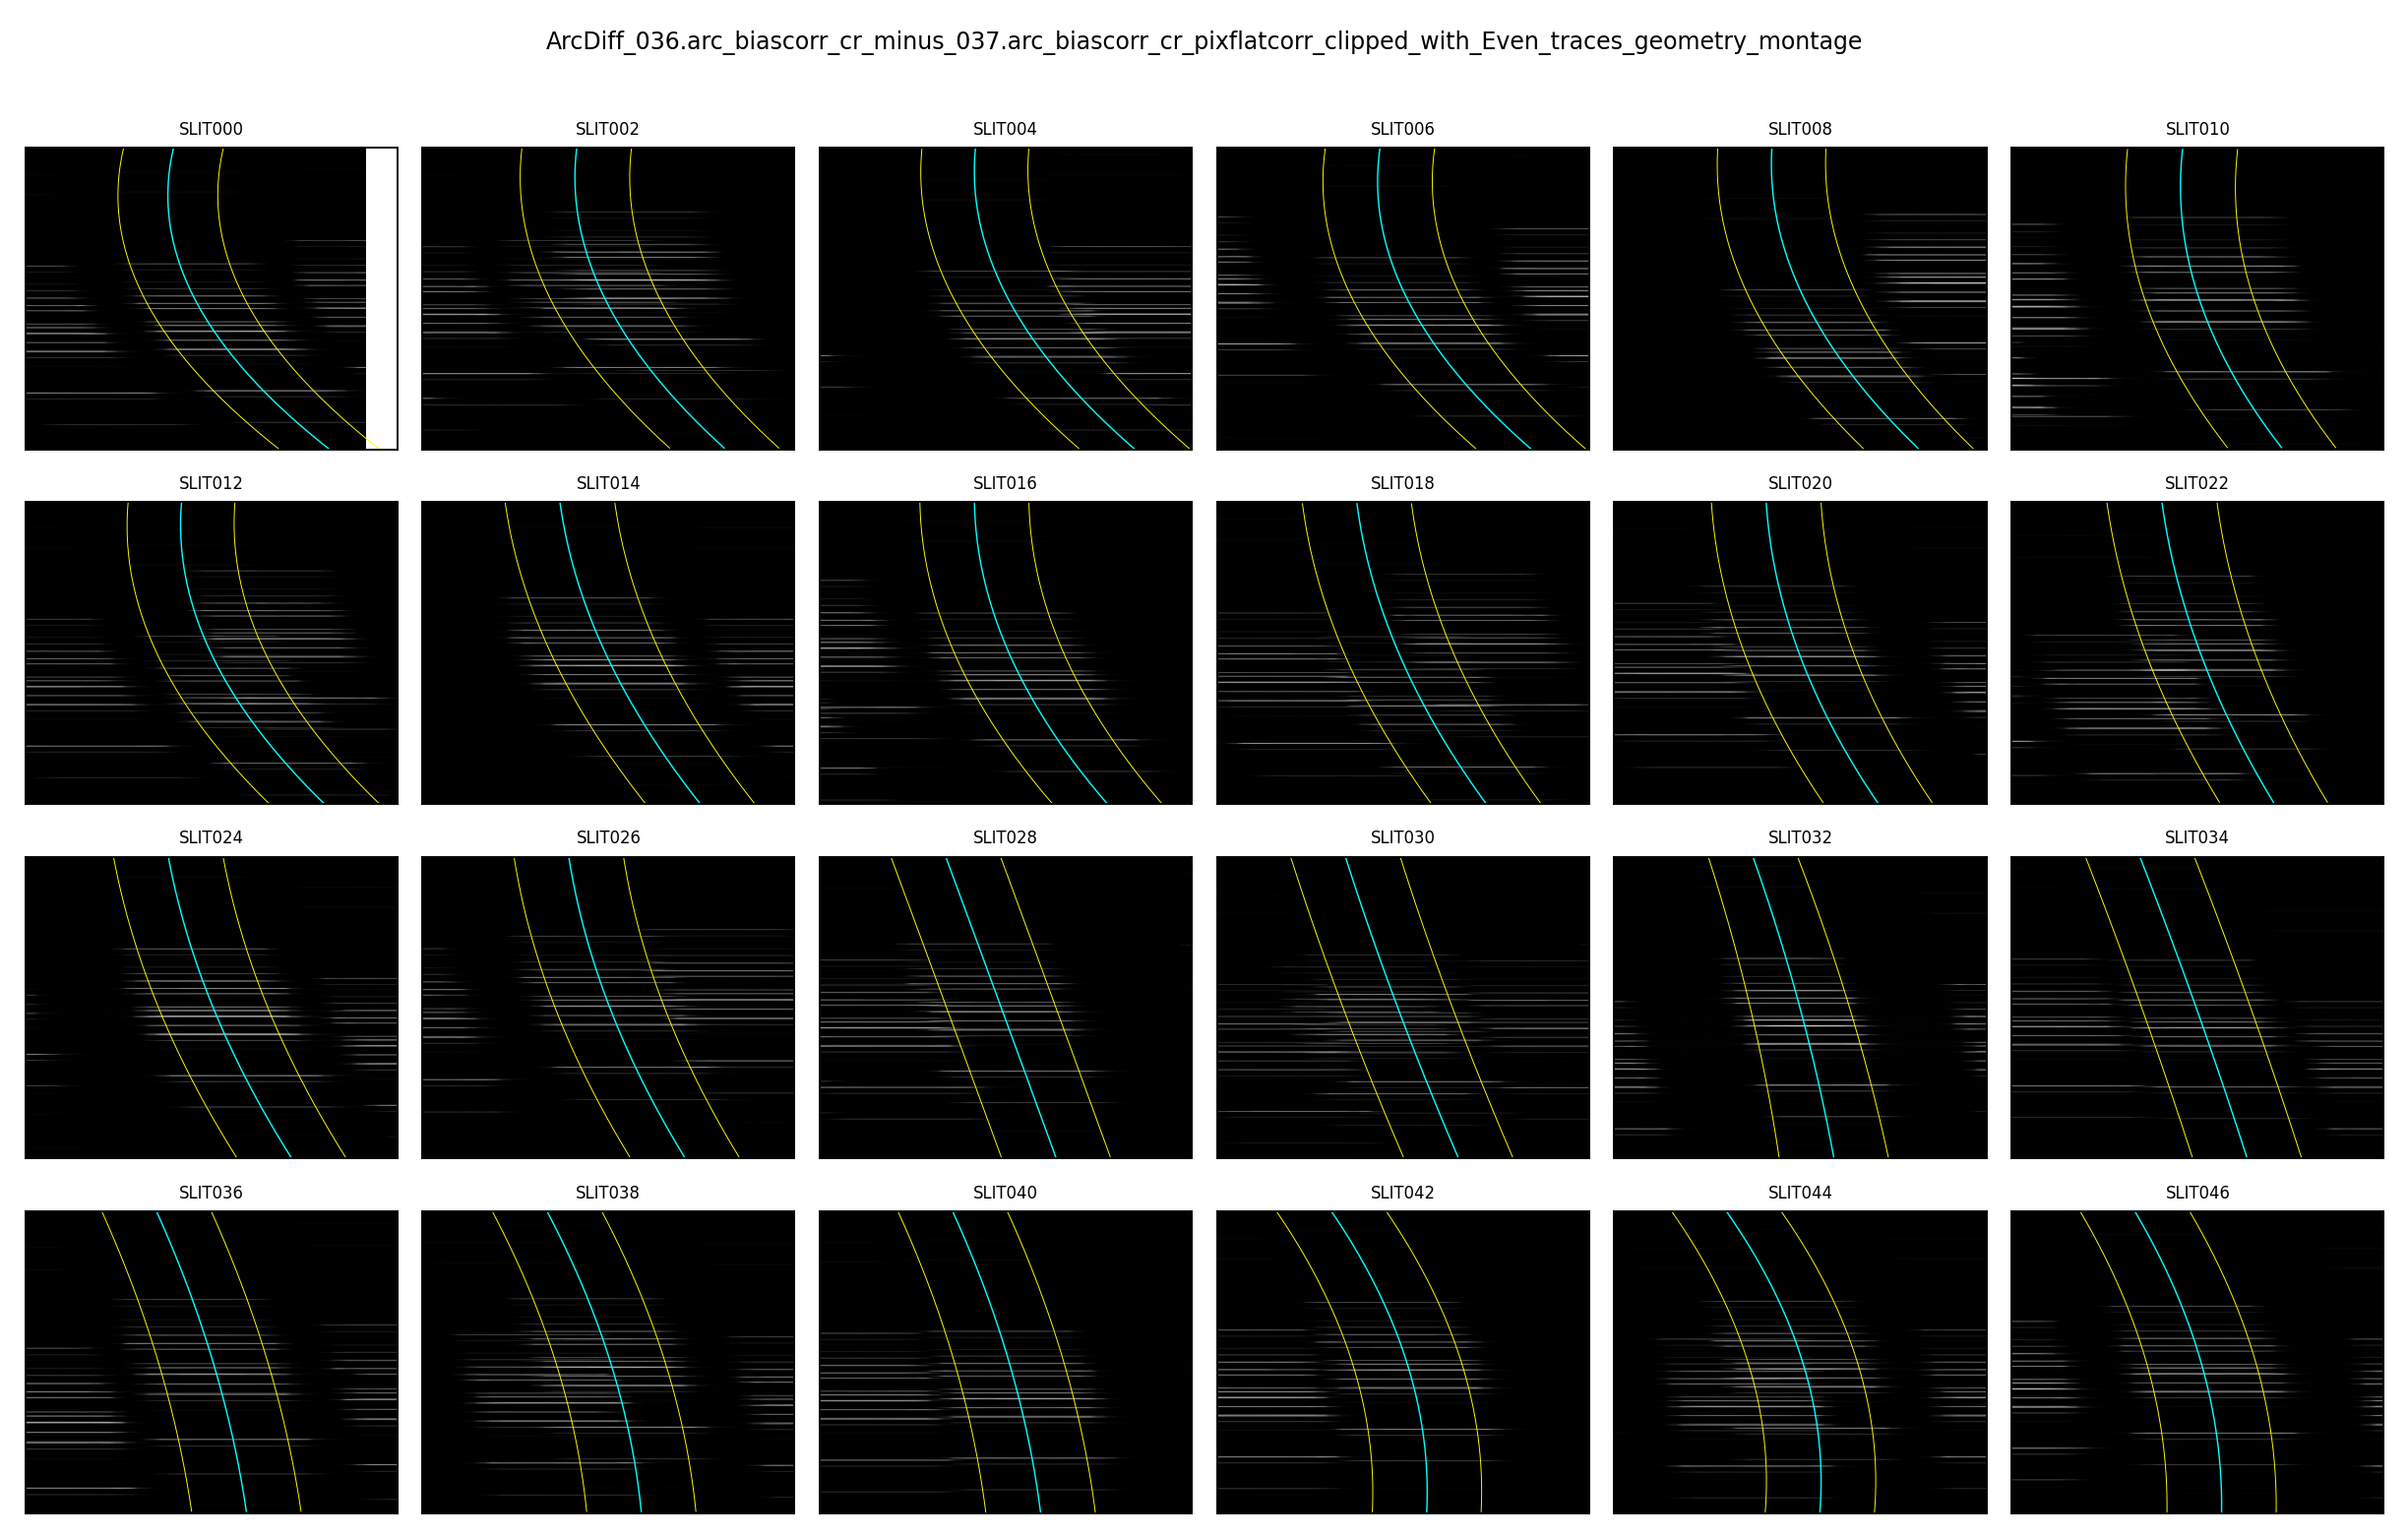

### ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_with_Odd_traces_geometry_montage.png

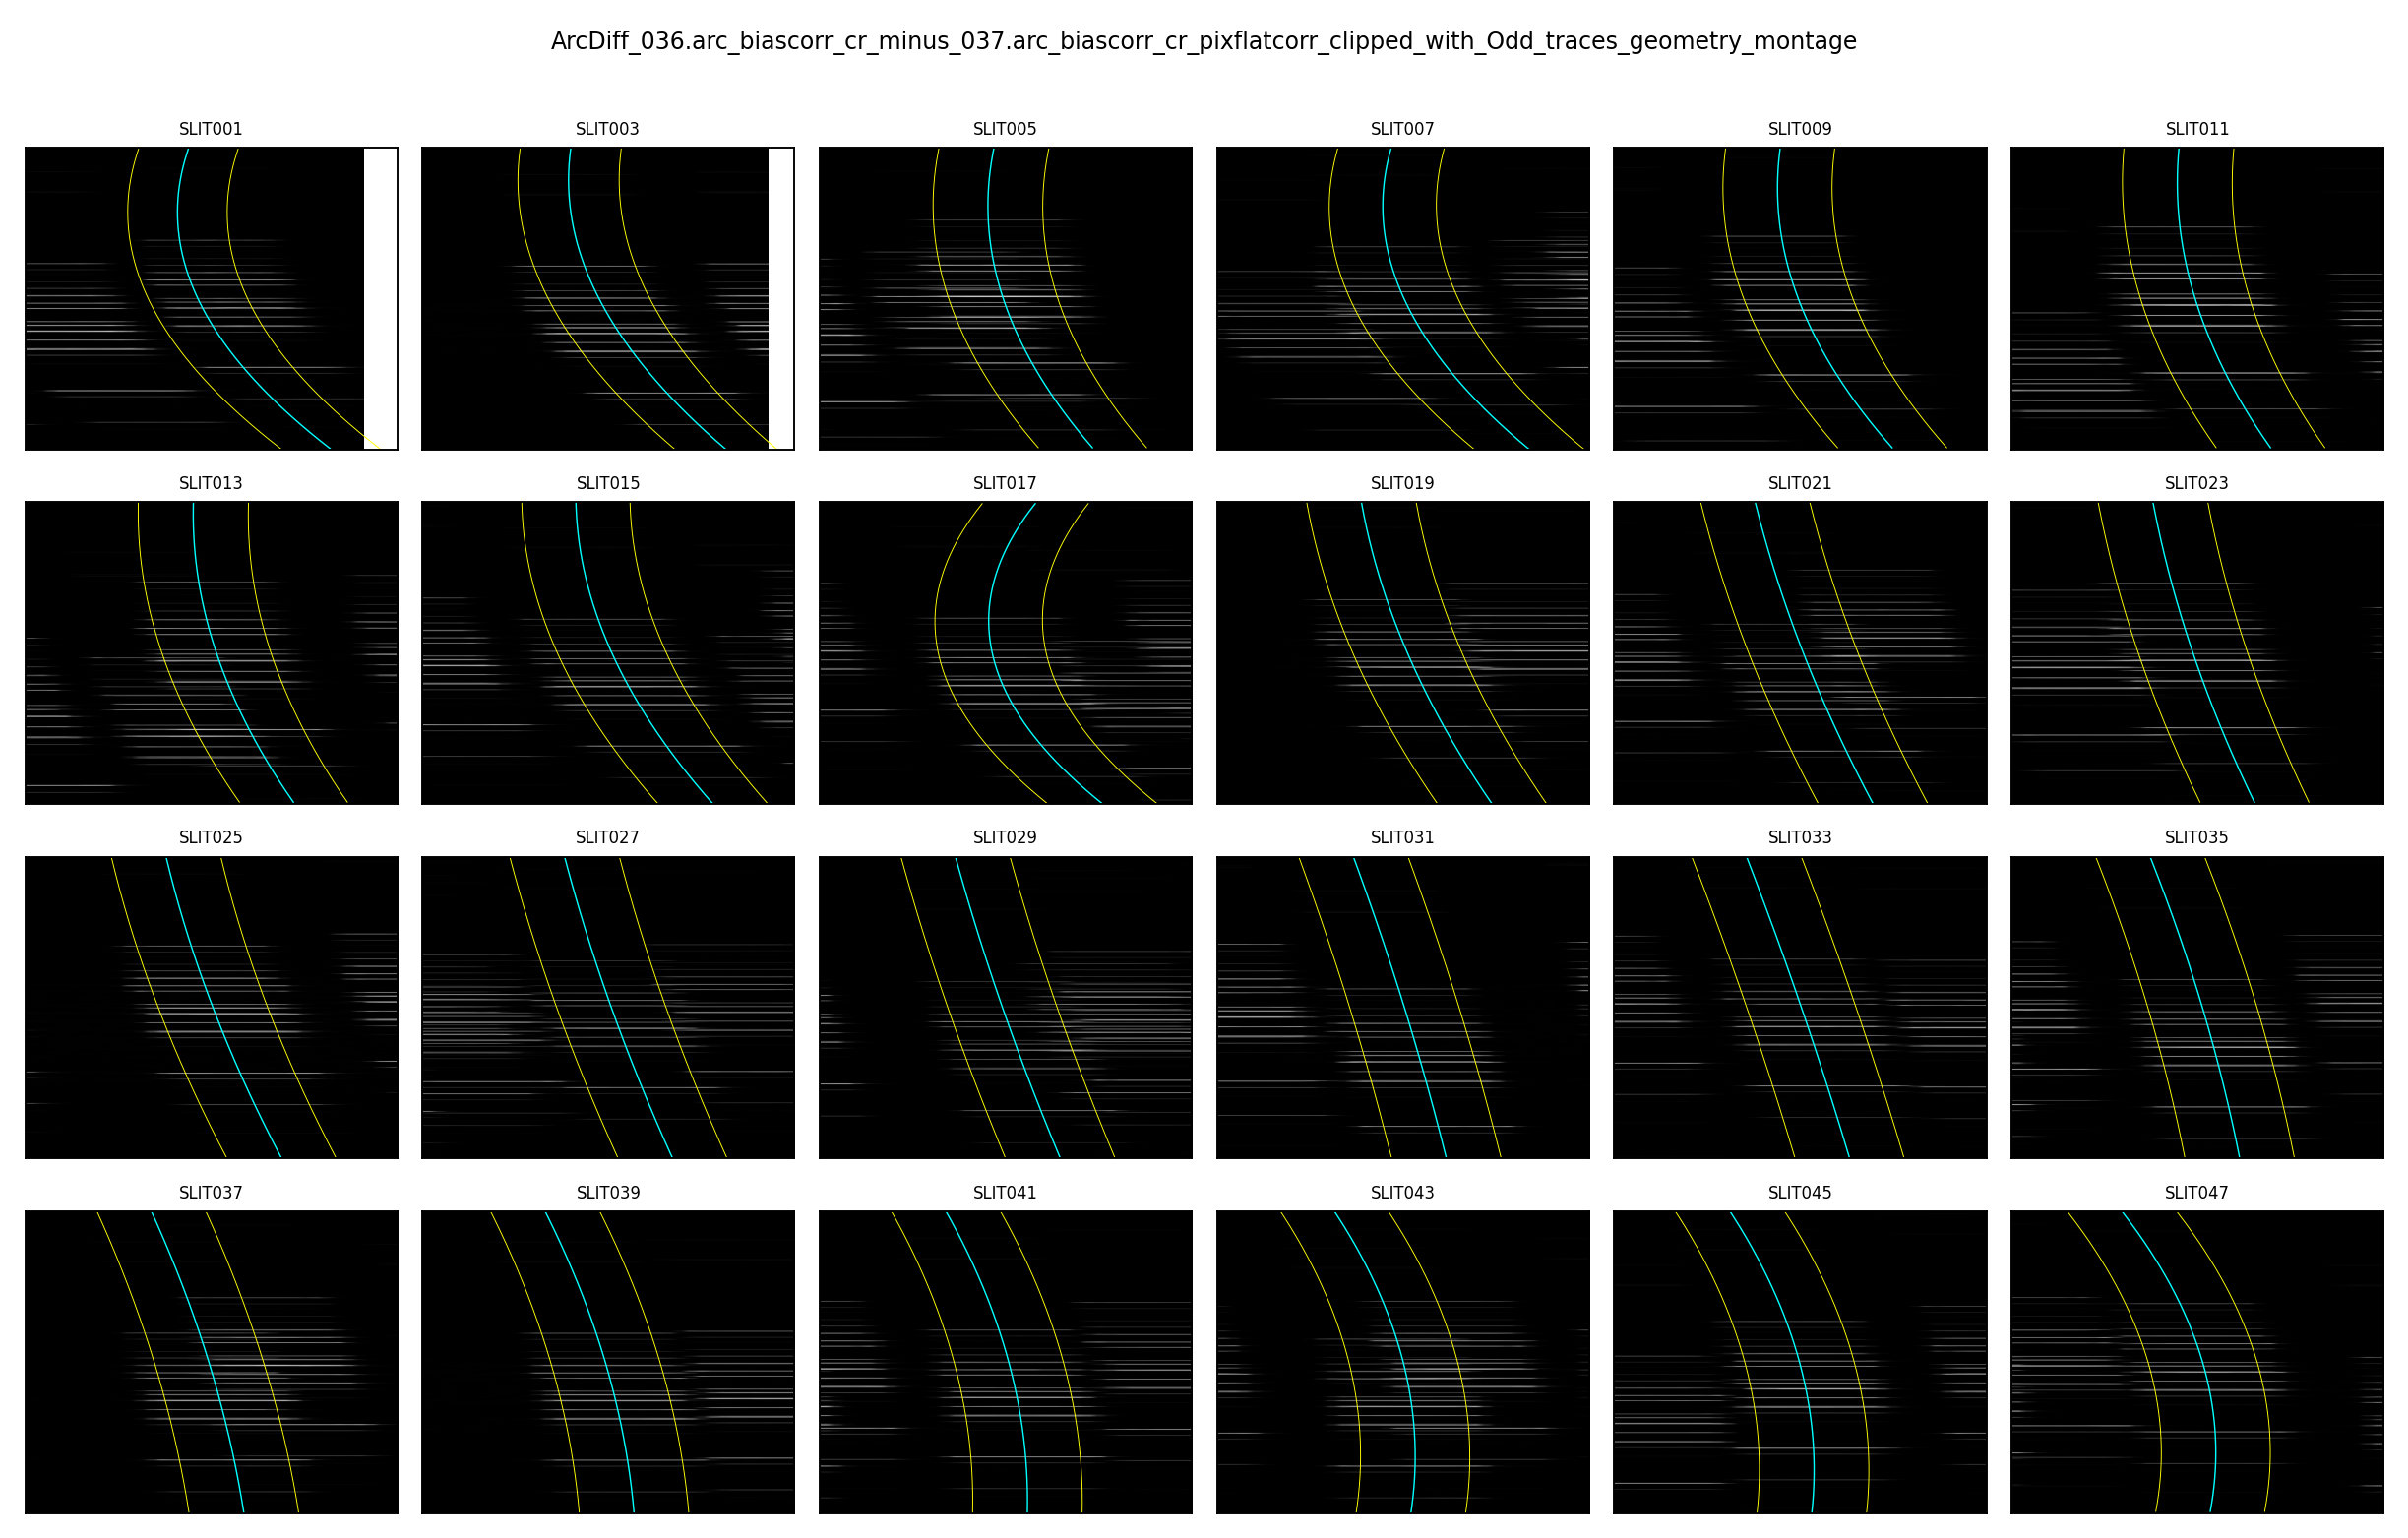

In [15]:
from pathlib import Path
from IPython.display import display, Image, Markdown
import config

st07 = Path(config.ST07_WAVECAL)

patterns = [
    "*overlay*/*with_Even_traces_geometry_montage.png",
    "*overlay*/*with_Odd_traces_geometry_montage.png",
]

hits = []
for pat in patterns:
    hits.extend(sorted(st07.glob(pat)))
    hits.extend(sorted((st07 / "qc_step07g").glob(pat)) if (st07 / "qc_step07g").exists() else [])

# remove duplicates while preserving order
seen = set()
uniq = []
for p in hits:
    if p not in seen:
        uniq.append(p)
        seen.add(p)

if not uniq:
    print("No Step07 geometry montage PNGs found.")
else:
    for p in uniq:
        display(Markdown(f"### {p.name}"))
        display(Image(filename=str(p)))

In [16]:
# Uncomment to run Step07g QC
run_repo_script("qc/step07/qc07g_inspect_wavelength_solution.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07g_inspect_wavelength_solution.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
MASTER_WAVESOL = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master_wavesol.fits
GLOBAL_WAVESOL = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_wavesol_per_slit.fits
ARC1D_EVEN     = /Users/robberto/Librar

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07g_inspect_wavelength_solution.py'], returncode=0)

## Print the three plots produced by the 07g script

3
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/step07g_master_peaks_used.png


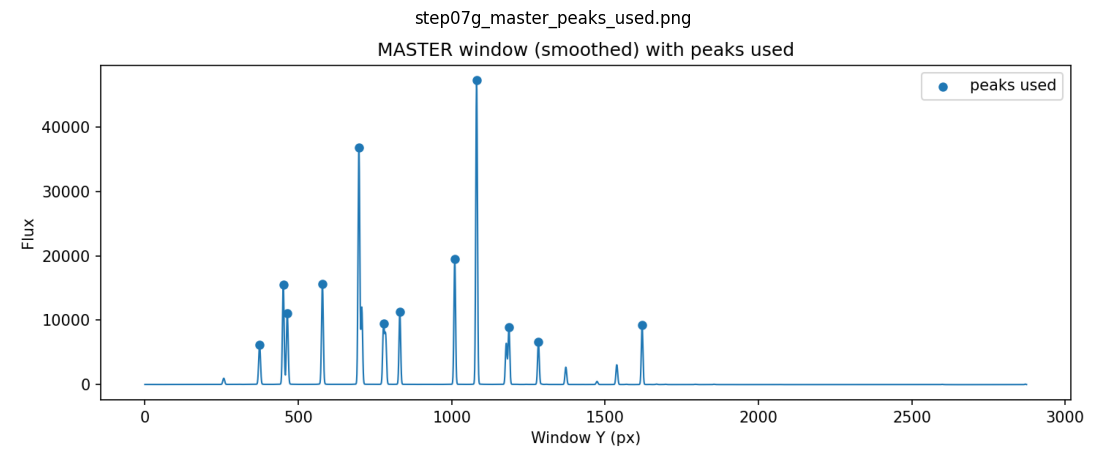

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/step07g_master_residuals.png


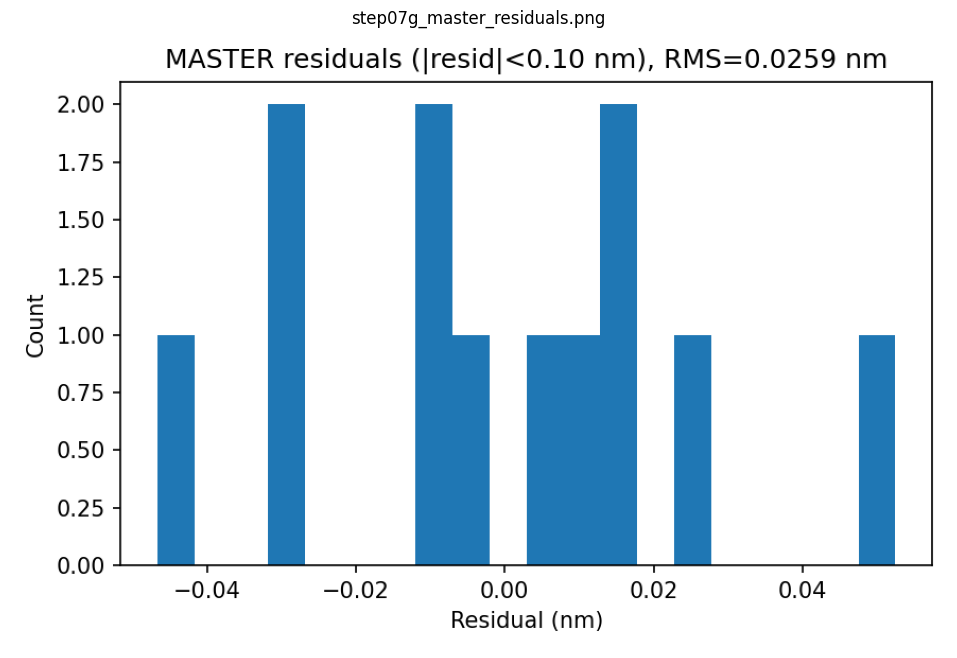

Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/step07g_slit_spectra_wavelength.png


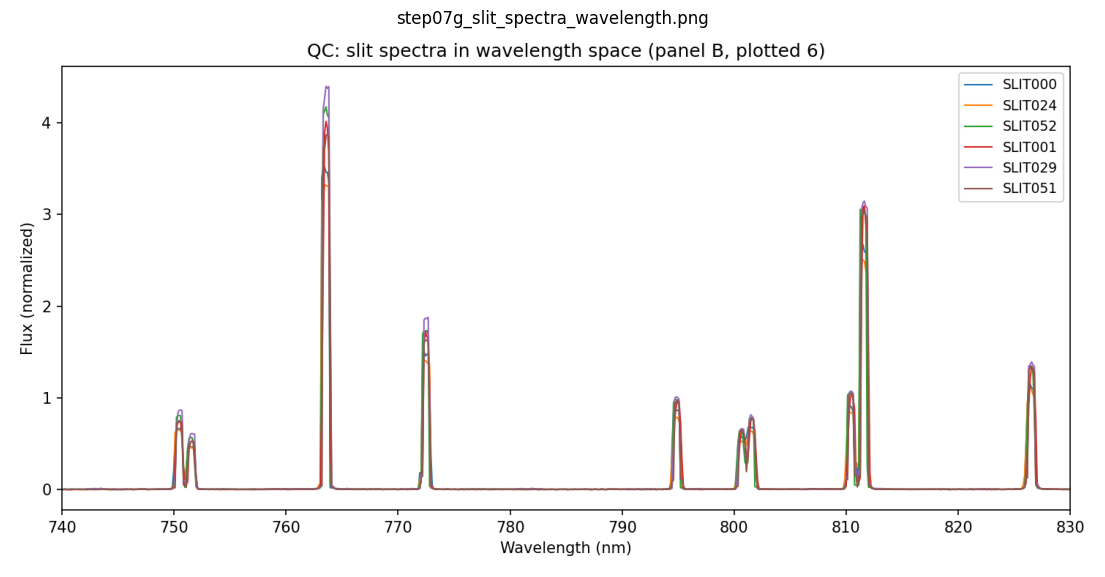

In [17]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

st07 = Path(config.ST07_WAVECAL)

patterns = [
    "*step07g*.png",
]

hits = []
search_dirs = [st07, st07 / "qc_step07g", st07 / "qc_step07h"]
for d in search_dirs:
    if not d.exists():
        continue
    for pat in patterns:
        hits.extend(sorted(d.glob(pat)))

print(len(hits))

seen = set()
uniq = []
for p in hits:
    if p not in seen and p.exists():
        seen.add(p)
        uniq.append(p)

if not uniq:
    print("No saved Step07 QC figures found in", st07)
else:
    for p in uniq[:12]:
        print("Displaying:", p)
        img = Image.open(p)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(p.name)
        plt.show()


In [18]:
# Step07g QC — global wavelength solution (independent of manual tweaks)

from pathlib import Path
import config

st07 = Path(config.ST07_WAVECAL)

# Optional: explicitly set the input file
wavesol = st07 / "arc_master_wavesol.fits"

print("Running Step07g QC on:", wavesol, wavesol.exists())

run_repo_script(
    "qc/step07/qc07g_wavelength_solution_final.py",
    "--fits",
    str(wavesol)
)

Running Step07g QC on: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master_wavesol.fits True
Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07g_wavelength_solution_final.py --fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master_wavesol.fits
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
[DONE] Wrote /Users/robberto/Library/Cloud

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07g_wavelength_solution_final.py', '--fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master_wavesol.fits'], returncode=0)

## Print the wave solution diagnosic from 07g

1
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07g/qc07g_wavesol_summary.png


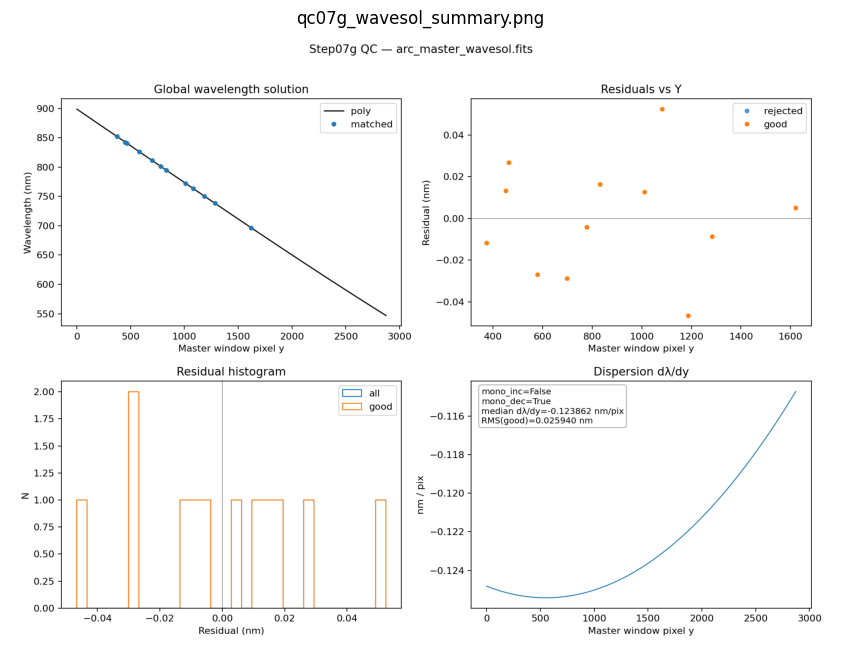

In [19]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image

st07 = Path(config.ST07_WAVECAL)

patterns = [
    "*wavesol*.png",
]

hits = []
search_dirs = [st07, st07 / "qc_step07g", st07 / "qc_step07h"]
for d in search_dirs:
    if not d.exists():
        continue
    for pat in patterns:
        hits.extend(sorted(d.glob(pat)))

print(len(hits))

seen = set()
uniq = []
for p in hits:
    if p not in seen and p.exists():
        seen.add(p)
        uniq.append(p)

if not uniq:
    print("No saved Step07 QC figures found in", st07)
else:
    for p in uniq[:12]:
        print("Displaying:", p)
        img = Image.open(p)
        plt.figure(figsize=(14, 8))
        plt.imshow(img)
        plt.axis("off")
        plt.title(p.name)
        plt.show()

In [20]:
from pathlib import Path
from shutil import copy2
import config

st07 = Path(config.ST07_WAVECAL)

# Find the canonical Step07c slitid products
even_candidates = sorted(st07.glob("*_1D_slitid_EVEN.fits"))
odd_candidates  = sorted(st07.glob("*_1D_slitid_ODD.fits"))

if not even_candidates:
    raise FileNotFoundError(f"No *_1D_slitid_EVEN.fits found in {st07}")
if not odd_candidates:
    raise FileNotFoundError(f"No *_1D_slitid_ODD.fits found in {st07}")

src_even = even_candidates[-1]
src_odd  = odd_candidates[-1]

dst_even = st07 / "arc_1d_even.fits"
dst_odd  = st07 / "arc_1d_odd.fits"

print("Source EVEN:", src_even)
print("Source ODD :", src_odd)
print("Dest EVEN  :", dst_even)
print("Dest ODD   :", dst_odd)

copy2(src_even, dst_even)
copy2(src_odd, dst_odd)

print("\nWrote:")
print(" ", dst_even, dst_even.exists())
print(" ", dst_odd,  dst_odd.exists())

Source EVEN: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_EVEN.fits
Source ODD : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/ArcDiff_036.arc_biascorr_cr_minus_037.arc_biascorr_cr_pixflatcorr_clipped_1D_slitid_ODD.fits
Dest EVEN  : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_even.fits
Dest ODD   : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_odd.fits

Wrote:
  /Users/rob

## 10. Step07h — propagate the wavelength solution to all slits

Step07h uses the master wavelength solution together with the `SHIFT_TO_MASTER` bookkeeping to attach wavelength vectors to all slit arc spectra.

Conceptually, for each slit:

```text
y_master = y_local + SHIFT_TO_MASTER
lambda_nm = poly(y_master)
```


In [21]:
# Uncomment to run Step07h
run_repo_script("pipeline/step07_wavecal/step07h_propagate_wavesol.py")


Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07h_propagate_wavesol.py
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline


2026-04-10 19:10:00,076 | INFO     | step07h_propagate | ARC1D_EVEN = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_even.fits
2026-04-10 19:10:00,076 | INFO     | step07h_propagate | ARC1D_ODD  = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_odd.fits
2026-04-10 19:10:00,076 | INFO     | step07h_propagate | MASTER_ALL = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_master.fits
2026-04-10 19:10:00,076 | INFO     | step07h_propagate | MASTER_SOL = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step07_wavecal/step07h_propagate_wavesol.py'], returncode=0)

## Analyze Vertical Bars: Zoom in

In [22]:
xlim_0 = 805
xlim_1 = 818
run_repo_script(
    "qc/step07/qc07h_vertical_lines_compare.py",
    "--fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all_trial_tweak.fits"),
    "--ref-fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all.fits"),
    "--xlim", str(xlim_0), str(xlim_1),
    "--lines", "811.5311",
    "--highlight-slit", "SLIT001"
)

Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py --fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits --ref-fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits --xlim 805 818 --lines 811.5311 --highlight-slit SLIT001
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/sa

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py', '--fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits', '--ref-fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits', '--xlim', '805', '818', '--lines', '811.5311', '--highlight-slit', 'SLIT001'], returncode=0)

## Display

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_805_818.png
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_805_818.png


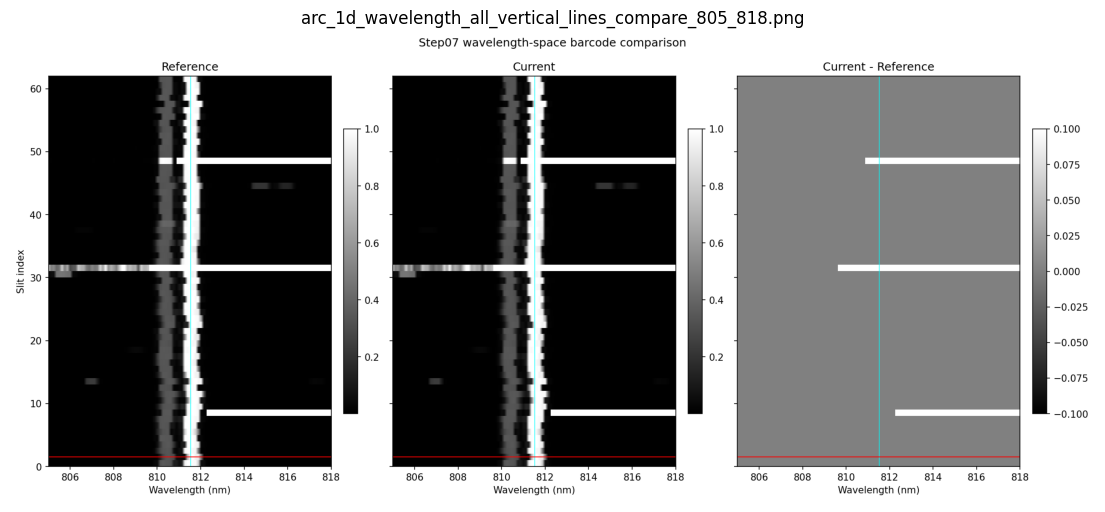

In [23]:
stringa = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+".png"
print(stringa)
p = st07 / stringa
print("Displaying:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
plt.show()

## Analyze Vertical Bars: Full Field

In [24]:
xlim_0 = 550
xlim_1 = 900
run_repo_script(
    "qc/step07/qc07h_vertical_lines_compare.py",
    "--fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all_trial_tweak.fits"),
    "--ref-fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all.fits"),
    "--xlim", str(xlim_0), str(xlim_1),
    "--lines", "811.5311",
    "--highlight-slit", "SLIT001"
)

Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py --fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits --ref-fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits --xlim 550 900 --lines 811.5311 --highlight-slit SLIT001
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/sa

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py', '--fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits', '--ref-fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits', '--xlim', '550', '900', '--lines', '811.5311', '--highlight-slit', 'SLIT001'], returncode=0)

In [25]:
### Display 3 plots in a single page

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900.png
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900.png


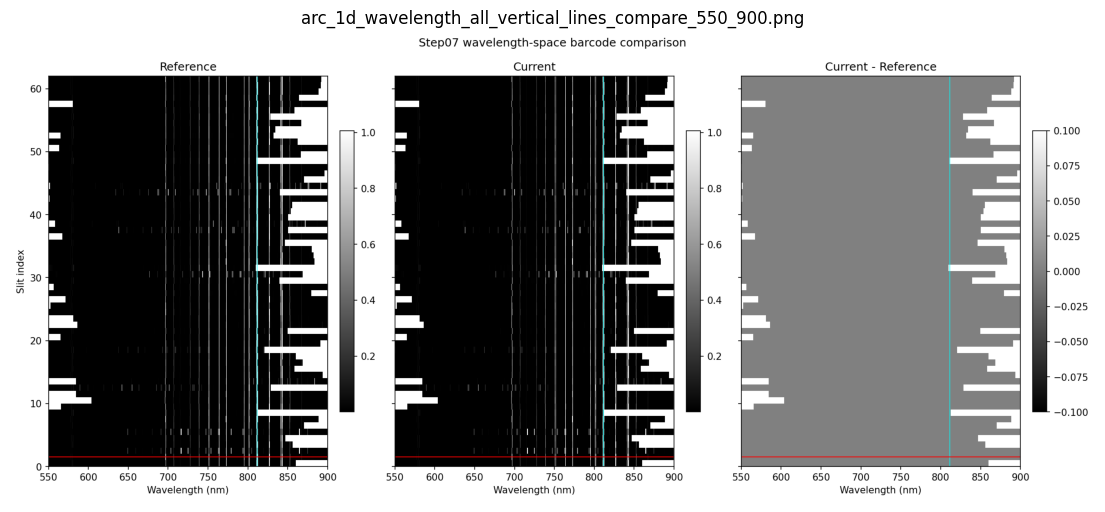

In [26]:
stringa = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+".png"
print(stringa)
p = st07 / stringa
print("Displaying:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
plt.show()

## Display individual plots

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png


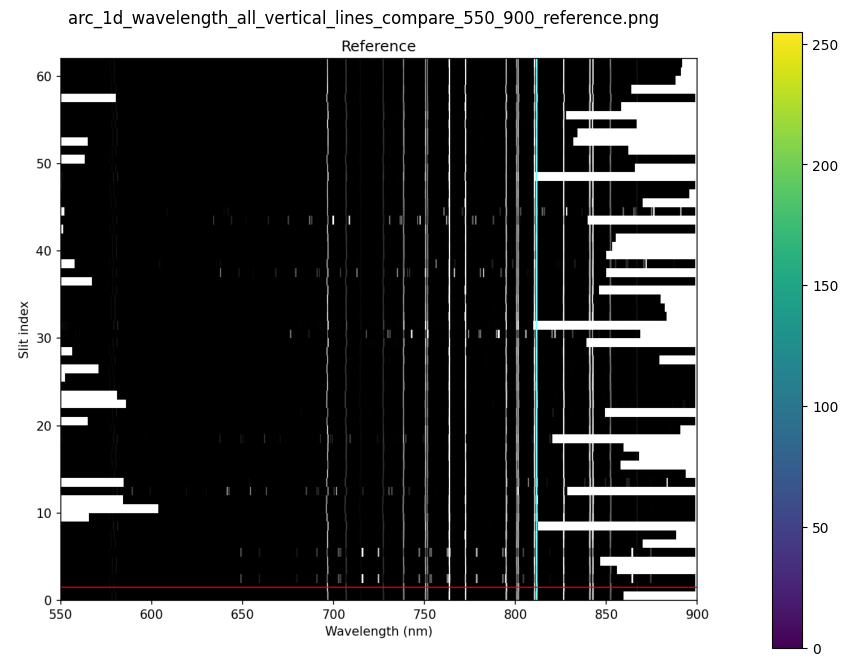

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png
current: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_current.png


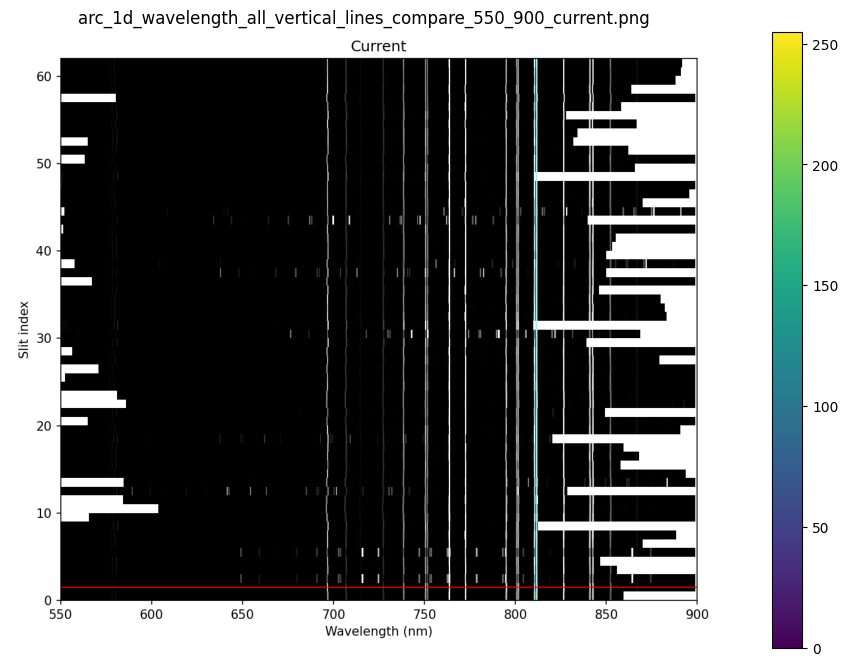

In [27]:
reference = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_reference.png"
current = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_current.png"
diff = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_diff.png"

print(reference)
p = st07 / reference
print("Displaying:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
cbar = plt.colorbar()
#cbar.set_label('X+Y')
plt.show()

print(reference)
p = st07 / current
print("current:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
cbar = plt.colorbar()
#cbar.set_label('X+Y')
plt.show()

# 11. OPTIONAL: Manual Wavelength-space zero-point tweaks via `ZEROPOINT_SHIFT_NM` for selected slits

This is the main interactive tuning cell.

Workflow:
1. run the notebook once with no correction
2. inspect the final plots / diagnostics
3. edit the dictionary below for one or a few bad slits
4. rerun from this cell downward
5. inspect again and repeat until satisfied

This cell does **not** overwrite the original master file. It writes:
- a patched trial master FITS
- a CSV log of the old and new values


In [29]:
from pathlib import Path
from astropy.io import fits
import numpy as np
import config

st07 = Path(config.ST07_WAVECAL)

ZEROPOINT_SHIFT_NM = {
    # "SLIT001": 20.0,
}

infile = st07 / "arc_1d_wavelength_all.fits"
outfile = st07 / "arc_1d_wavelength_all_trial_tweak.fits"

print("Input :", infile)
print("Output:", outfile)
print("ZEROPOINT_SHIFT_NM =", ZEROPOINT_SHIFT_NM)

if not ZEROPOINT_SHIFT_NM:
    ACTIVE_WAV_FITS = infile
    print("No manual tweak requested; using baseline file.")
    print("ACTIVE_WAV_FITS =", ACTIVE_WAV_FITS)
else:
    with fits.open(infile) as hdul:
        new = fits.HDUList([h.copy() for h in hdul])

        changed = []

        for hdu in new[1:]:
            slit = (hdu.header.get("EXTNAME") or hdu.name or "").strip().upper()
            if slit not in ZEROPOINT_SHIFT_NM:
                continue

            arr = np.asarray(hdu.data, float)
            if arr.ndim < 2 or arr.shape[0] < 2:
                raise ValueError(f"{slit}: unexpected shape {arr.shape}")

            dlam = float(ZEROPOINT_SHIFT_NM[slit])
            arr[1] = arr[1] + dlam
            hdu.data = arr
            hdu.header["LAMSHIFT"] = (dlam, "Manual trial wavelength zero-point shift [nm]")

            changed.append((slit, dlam))
            print(f"{slit}: applied {dlam:+.3f} nm")

    if not changed:
        raise RuntimeError("No requested slits were found; no trial file written.")

    new[0].header["HISTORY"] = "Manual trial slit wavelength zero-point shifts applied in notebook"
    new.writeto(outfile, overwrite=True)

    ACTIVE_WAV_FITS = outfile
    print("\nWrote:", outfile)
    print("ACTIVE_WAV_FITS =", ACTIVE_WAV_FITS)

Input : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits
Output: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits
ZEROPOINT_SHIFT_NM = {}
No manual tweak requested; using baseline file.
ACTIVE_WAV_FITS = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits


### Useful to remember: approximate wavelength-to-pixel helper

Use this only as a first guess when you estimate a slit error by eye in nm.
The actual tuning should be done by editing `SHIFT_PATCH` and rerunning from the patch cell downward.


In [30]:
delta_lambda_nm = 50.0
dispersion_nm_per_pix = 0.124
delta_pix = delta_lambda_nm / dispersion_nm_per_pix
print(f"Approximate pixel shift for {delta_lambda_nm:.3f} nm: {delta_pix:.1f} px")


Approximate pixel shift for 50.000 nm: 403.2 px


### Rerun propagation after patching the trial master

This notebook assumes the next propagation should use the **trial patched master**.
If your `step07h_propagate_wavesol.py` does not yet accept an explicit `--master` argument,
use your normal config workflow to temporarily point `config.MASTER_ARC_FITS` to the trial file before rerunning.


In [31]:
# Preferred workflow if Step07h is later upgraded to accept --master:
#
#trial_master = Path(config.MASTER_ARC_FITS).expanduser().with_name(
#     Path(config.MASTER_ARC_FITS).expanduser().stem + "_trial_shiftpatch.fits"
# )
#run_repo_script("pipeline/step07_wavecal/step07h_propagate_wavesol.py", "--master", str(trial_master))

# Current fallback:
# adopt the trial master through your normal config workflow, then rerun Step07h
# run_repo_script("pipeline/step07_wavecal/step07h_propagate_wavesol.py")

xlim_0 = 550
xlim_1 = 900
run_repo_script(
    "qc/step07/qc07h_vertical_lines_compare.py",
    "--fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all_trial_tweak.fits"),
    "--ref-fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all.fits"),
    "--xlim", str(xlim_0), str(xlim_1),
    "--lines", "811.5311",
    "--highlight-slit", "SLIT001"
)



Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py --fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits --ref-fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits --xlim 550 900 --lines 811.5311 --highlight-slit SLIT001
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/sa

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py', '--fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits', '--ref-fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits', '--xlim', '550', '900', '--lines', '811.5311', '--highlight-slit', 'SLIT001'], returncode=0)

## CHECK THE RESULT TO ITERATE

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png
Displaying: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png


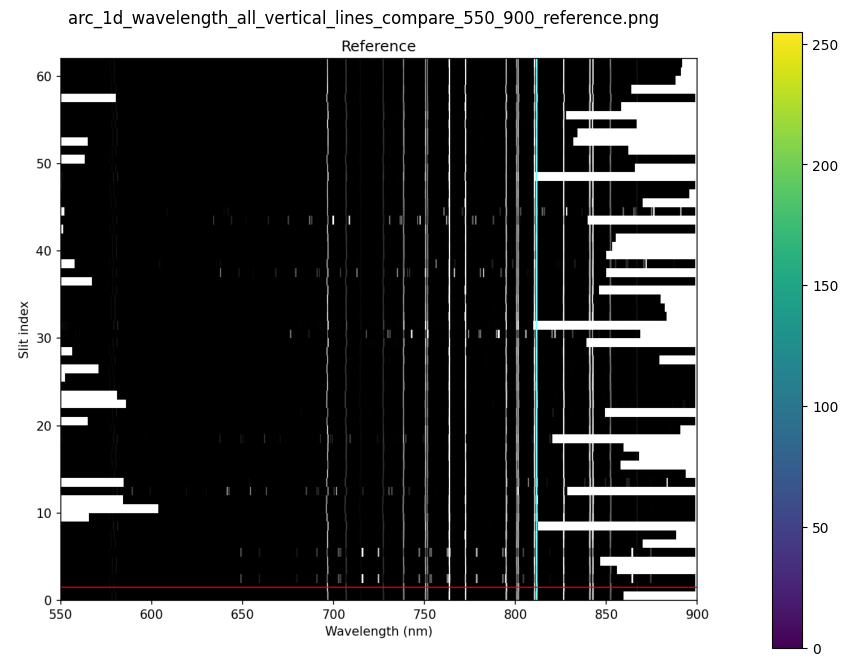

qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_reference.png
current: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_550_900_current.png


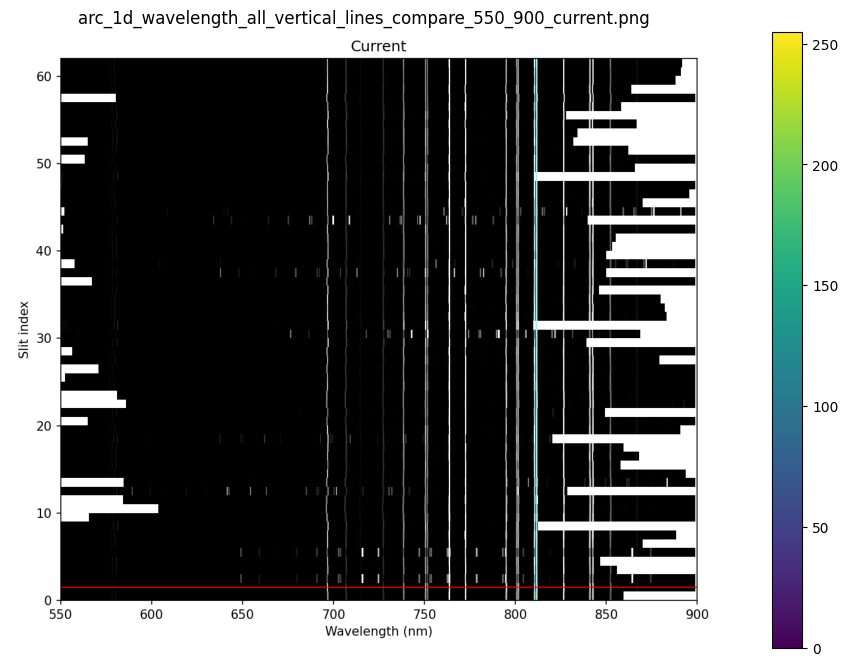

In [32]:
reference = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_reference.png"
current = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_current.png"
diff = "qc_step07h/arc_1d_wavelength_all_vertical_lines_compare_"+str(xlim_0)+"_"+str(xlim_1)+"_diff.png"

print(reference)
p = st07 / reference
print("Displaying:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
cbar = plt.colorbar()
#cbar.set_label('X+Y')
plt.show()

print(reference)
p = st07 / current
print("current:", p)
img = Image.open(p)
plt.figure(figsize=(14, 8))
plt.imshow(img)
plt.axis("off")
plt.title(p.name)
cbar = plt.colorbar()
#cbar.set_label('X+Y')
plt.show()

## END OF OPTIONAL FINE TUNING: REMINDER: 

### *arc_1d_wavelength_all_trial_tweak.fits*: temporary trial product used only during manual tuning. 
### Once a solution is accepted, it must be promoted to *arc_1d_wavelength_all.fits*, which remains the single canonical wavelength solution consumed by downstream steps.

## 12. Final scientific QC in wavelength space

This is the strongest end-to-end validation of Step07.

Once Step07h has propagated wavelength vectors to all slits, you can validate the solution in three complementary ways:

1. **Visual straight-line test**
2. **Global quantitative QC**
3. **Representative per-slit inspection**


In [33]:
run_repo_script(
    "qc/step07/qc07h_vertical_lines_compare.py",
    "--fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all_trial_tweak.fits"),
    "--ref-fits",
    str(Path(config.ST07_WAVECAL) / "arc_1d_wavelength_all.fits"),
    "--xlim", "805", "818",
    "--lines", "811.5311",
    "--highlight-slit", "SLIT001"
)

Running: /opt/anaconda3/envs/samos/bin/python /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py --fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits --ref-fits /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits --xlim 805 818 --lines 811.5311 --highlight-slit SLIT001
cwd     : /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
PYTHONPATH: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/sa

CompletedProcess(args=['/opt/anaconda3/envs/samos/bin/python', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step07/qc07h_vertical_lines_compare.py', '--fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all_trial_tweak.fits', '--ref-fits', '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/07_wavecal/arc_1d_wavelength_all.fits', '--xlim', '805', '818', '--lines', '811.5311', '--highlight-slit', 'SLIT001'], returncode=0)

### 13. Minimal end-to-end Step07 checklist

A practical Step07 session usually looks like this:

1. run Step07a
2. run Step07b
3. run Step07c for EVEN and ODD
4. verify Step04 geometry over the arc image
5. run Step07d for EVEN and ODD
6. inspect bright-line alignment
7. run Step07e for EVEN and ODD
8. run Step07f
9. inspect the master arc
10. run Step07g
11. inspect wavelength-solution residuals
12. run Step07h
13. run the vertical-line QC and the global quantitative QC


## 14. What a good Step07 result should look like

### Early arc stages
- Step04 geometry follows the intended arc ridge
- extracted arc1d spectra are plausible
- bright lines align cleanly after Step07d/07e

### Master arc stage
- aligned stack shows a vertically aligned bright line
- coverage is smooth and bookkeeping is consistent

### Wavelength-solution stage
- fitted residuals are small
- selected slit spectra line up in wavelength space
- wavelength coverage is sensible and stable across slits

### Final propagated stage
- emission lines are vertical in the all-slits wavelength-space view
- wavelength vectors are monotonic
- worst-slit ranking reveals only a few edge/pathological cases


## 16. Summary of the Step07 philosophy

The real strength of Step07 is that it supports layered validation:

- geometry validation
- alignment validation
- master-arc validation
- wavelength-fit validation
- final wavelength-space validation

That means Step07 is not just a black box that outputs wavelengths: it provides several independent ways to judge whether the calibration is scientifically trustworthy.
